# YOLOv26n Plankton Detection - Comprehensive Training Pipeline

## Overview

This notebook implements a complete YOLOv26n training pipeline for plankton detection using:
- **5-Fold Cross Validation** for robust model evaluation
- **Roboflow Dataset** with COCO format export
- **YOLOv26n Default Hyperparameters** for optimal inference speed
- **Comprehensive Metrics** including mAP@0.5, mAP@0.5:0.95, F1-score

| Aspect | YOLOv26n | Faster RCNN |
|--------|---------|------------|
| Model Size | ~7 MB | ~140 MB |
| Inference Speed | 100+ FPS | ~15 FPS |
| Architecture | Single-stage | Two-stage |
| Batch Size | 16 | 1 |
| Epochs | 100 | 80 |
| Learning Rate | 0.01 | 0.001 |

## Pipeline Structure

```
1. Import Libraries & GPU Setup
   ↓
2. Download Dataset from Roboflow
   ↓
3. Configuration & Hyperparameters
   ↓
4. Dataset Preparation (COCO to YOLO Format)
   ↓
5. YOLOv26n Model Initialization
   ↓
6. 5-Fold Cross Validation Training
   ↓
7. Evaluation & Metrics Calculation
   ↓
8. Inference & Visualization
   ↓
9. Results Analysis & Comparison
```

---

## 1. Import Libraries & GPU Setup

In [ ]:
import os
import sys
import json
import yaml
import shutil
import warnings
import subprocess
import logging
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

try:
    from ultralytics import YOLO
    print("✓ YOLOv8 already installed")
except ImportError:
    print("Installing YOLOv8...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO
    print("✓ YOLOv8 installed successfully")

# Suppress warnings
warnings.filterwarnings('ignore')
logging.getLogger('ultralytics').setLevel(logging.WARNING)

# Check environment
print("\n" + "="*80)
print("ENVIRONMENT CHECK")
print("="*80)
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
print(f"Platform: {sys.platform}")
print("="*80)

Installing YOLOv8...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ YOLOv8 installed successfully

ENVIRONMENT CHECK
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA Available: True
CUDA Device: Tesla T4
Platform: linux


In [ ]:
!nvidia-smi

Mon Jun  8 12:57:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Download Dataset from Roboflow

In [ ]:
print("\n" + "="*80)
print("COMPLETE ROBOFLOW DATASET DOWNLOAD WITH FALLBACK MECHANISM")
print("="*80 + "\n")

# Roboflow dataset link
ROBOFLOW_LINK = "https://app.roboflow.com/ds/XMFWM8OwUN?key=tY0B1mvERs"

def explore_directory(path, max_depth=2, current_depth=0, prefix=""):
    """Recursively explore and display directory structure"""
    if current_depth >= max_depth:
        return

    try:
        items = os.listdir(path)
        for item in items:
            item_path = os.path.join(path, item)
            print(f"{prefix}├── {item}")
            if os.path.isdir(item_path) and item not in ['.git', '__pycache__', '.ipynb_checkpoints']:
                explore_directory(item_path, max_depth, current_depth + 1, prefix + "│   ")
    except PermissionError:
        print(f"{prefix}├── [Permission Denied]")

# Check existing data
BASE_DIR = None
if os.path.exists('train') and os.path.exists('valid'):
    BASE_DIR = '.'
    print("✓ Dataset already exists locally (detected train/valid in current dir)")
elif os.path.exists('data'):
    BASE_DIR = 'data'
    print("✓ Dataset directory found at ./data")
else:
    print("ℹ  Dataset not found locally. Attempting Roboflow download...\n")

if BASE_DIR is None:
    # Try curl first (Windows/Unix)
    print("Step 1: Attempting download with curl...")
    try:
        result = subprocess.run(
            f'curl -L "{ROBOFLOW_LINK}" -o roboflow_dataset.zip 2>/dev/null',
            shell=True,
            capture_output=True,
            text=True,
            timeout=60
        )

        if os.path.exists('roboflow_dataset.zip') and os.path.getsize('roboflow_dataset.zip') > 1000000:
            print("✓ Download successful with curl (size: {:.2f} MB)".format(os.path.getsize('roboflow_dataset.zip')/1024/1024))
            BASE_DIR = 'data'
        else:
            raise Exception("Download failed or file too small")

    except Exception as e:
        print(f"✗ Curl failed: {str(e)}")
        print("\nStep 2: Attempting download with wget...")

        try:
            result = subprocess.run(
                f'wget -q -O roboflow_dataset.zip "{ROBOFLOW_LINK}" 2>/dev/null',
                shell=True,
                capture_output=True,
                text=True,
                timeout=60
            )

            if os.path.exists('roboflow_dataset.zip') and os.path.getsize('roboflow_dataset.zip') > 1000000:
                print("✓ Download successful with wget (size: {:.2f} MB)".format(os.path.getsize('roboflow_dataset.zip')/1024/1024))
                BASE_DIR = 'data'
            else:
                raise Exception("Download failed or file too small")

        except Exception as e2:
            print(f"✗ Wget failed: {str(e2)}")
            print("\n⚠️  Manual download required!")
            print(f"Please download from: {ROBOFLOW_LINK}")
            BASE_DIR = 'data'

# Extract if zip exists
if os.path.exists('roboflow_dataset.zip'):
    print("\nStep 3: Extracting dataset...")
    try:
        import zipfile
        with zipfile.ZipFile('roboflow_dataset.zip', 'r') as zip_ref:
            zip_ref.extractall('data')
        print("✓ Dataset extracted to ./data")
        BASE_DIR = 'data'

        # Cleanup
        os.remove('roboflow_dataset.zip')
        print("✓ Cleaned up zip file")

    except Exception as e:
        print(f"✗ Extraction failed: {str(e)}")

# Auto-detect dataset structure
if BASE_DIR:
    print(f"\nStep 4: Dataset structure:")
    explore_directory(BASE_DIR, max_depth=2)

    # Find actual data directories
    if not os.path.exists(os.path.join(BASE_DIR, 'train')):
        possible_dirs = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
        for d in possible_dirs:
            if os.path.exists(os.path.join(BASE_DIR, d, 'train')):
                BASE_DIR = os.path.join(BASE_DIR, d)
                print(f"\n✓ Auto-detected dataset in: {BASE_DIR}")
                break

print(f"\n✓ Dataset base directory: {BASE_DIR}")


COMPLETE ROBOFLOW DATASET DOWNLOAD WITH FALLBACK MECHANISM

ℹ  Dataset not found locally. Attempting Roboflow download...

Step 1: Attempting download with curl...
✓ Download successful with curl (size: 7.02 MB)

Step 3: Extracting dataset...
✓ Dataset extracted to ./data
✓ Cleaned up zip file

Step 4: Dataset structure:
├── README.roboflow.txt
├── train
│   ├── images
│   ├── labels
├── README.dataset.txt
├── data.yaml

✓ Dataset base directory: data


## 3. Configuration & Hyperparameters

In [ ]:
CONFIG = {
    # Output directories
    'base_dir': BASE_DIR,
    'train_dir': os.path.join(BASE_DIR, 'train'),
    'val_dir': os.path.join(BASE_DIR, 'valid'),
    'test_dir': os.path.join(BASE_DIR, 'test'),
    'output_dir': os.path.join(BASE_DIR, 'yolov26n_results'),
    'cv_base_dir': os.path.join(BASE_DIR, 'yolov26n_cv'),

    # Model configuration
    'model_name': 'yolo26n',
    'num_classes': 26,
    'input_size': 640,

    # Training hyperparameters (YOLOv8 defaults)
    'batch_size': 16,           # YOLOv8 default (vs 1 for Faster RCNN)
    'num_epochs': 100,          # YOLOv8 default (vs 80 for Faster RCNN)
    'learning_rate': 0.01,      # YOLOv8 default (vs 0.001 for Faster RCNN)
    'momentum': 0.937,          # YOLOv8 default (vs 0.9 for Faster RCNN)
    'weight_decay': 0.0005,     # YOLOv8 default
    'scheduler_type': 'cosine', # YOLOv8 default (vs 'step' for Faster RCNN)
    'patience': 20,             # Early stopping patience

    # Device configuration
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 0 if sys.platform == 'win32' else 4
}

# Create output directories
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(CONFIG['cv_base_dir'], exist_ok=True)

print("\n" + "="*80)
print("CONFIGURATION SUMMARY")
print("="*80)
print(f"Model: {CONFIG['model_name']}")
print(f"Batch Size: {CONFIG['batch_size']}")
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Learning Rate: {CONFIG['learning_rate']}")
print(f"Device: {CONFIG['device']}")
print(f"Output Directory: {CONFIG['output_dir']}")
print("="*80)

print("\n⚠️  Configuration Differences from Faster RCNN:")
print(f"  • Batch Size: YOLOv26n={CONFIG['batch_size']} vs Faster RCNN=1")
print(f"  • Epochs: YOLOv26n={CONFIG['num_epochs']} vs Faster RCNN=80")
print(f"  • Learning Rate: YOLOv26n={CONFIG['learning_rate']} vs Faster RCNN=0.001")
print(f"  • Scheduler: YOLOv26n={CONFIG['scheduler_type']} vs Faster RCNN=step")
print(f"\n✓ Configuration complete!")


CONFIGURATION SUMMARY
Model: yolo26n
Batch Size: 16
Epochs: 100
Learning Rate: 0.01
Device: cuda
Output Directory: data/yolov26n_results

⚠️  Configuration Differences from Faster RCNN:
  • Batch Size: YOLOv26n=16 vs Faster RCNN=1
  • Epochs: YOLOv26n=100 vs Faster RCNN=80
  • Learning Rate: YOLOv26n=0.01 vs Faster RCNN=0.001
  • Scheduler: YOLOv26n=cosine vs Faster RCNN=step

✓ Configuration complete!


## 4. Dataset Preparation for YOLOv8 (COCO to YOLO Format)

In [ ]:
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold

print("\n" + "="*80)
print("LOADING YOLOV8 FORMAT DATASET & CREATING 5-FOLD CV STRUCTURE")
print("="*80)

# Load data.yaml to get class names
dataset_yaml_path = os.path.join(CONFIG['base_dir'], 'data.yaml')
with open(dataset_yaml_path, 'r') as f:
    dataset_config = yaml.safe_load(f)

# Get class names from data.yaml
CLASS_NAMES = dataset_config.get('names', [])
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

CONFIG['num_classes'] = len(CLASS_NAMES)
print(f"✓ Loaded {len(CLASS_NAMES)} classes from data.yaml")
print(f"  Classes: {', '.join(CLASS_NAMES[:5])}{'...' if len(CLASS_NAMES) > 5 else ''}")

# Collect all image paths from train/images
train_images_dir = os.path.join(CONFIG['train_dir'], 'images')
all_images = []

if os.path.exists(train_images_dir):
    for img_file in os.listdir(train_images_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            all_images.append(os.path.join(train_images_dir, img_file))

print(f"\n✓ Total images found: {len(all_images)}")

# Outer split: 85% TrainVal | 15% Test
all_images_array = np.array(all_images)
np.random.seed(42)

trainval_imgs, test_imgs = train_test_split(all_images_array, test_size=0.15, random_state=42)

print(f"✓ Outer Split (85:15):")
print(f"  TrainVal: {len(trainval_imgs)} images")
print(f"  Test: {len(test_imgs)} images")

# --- Stratified 5-Fold CV structure ---
CV_FOLD_INFO = {}
NUM_FOLDS = 5
kf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42) # Changed to StratifiedKFold

# Prepare labels for StratifiedKFold
trainval_labels = []
label_dir = os.path.join(CONFIG['train_dir'], 'labels') # Labels for original train dir

for img_path in trainval_imgs:
    label_filename = os.path.splitext(os.path.basename(img_path))[0] + '.txt'
    label_file_path = os.path.join(label_dir, label_filename)

    current_image_classes = []
    if os.path.exists(label_file_path):
        with open(label_file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    try:
                        class_id = int(parts[0])
                        current_image_classes.append(class_id)
                    except ValueError:
                        # Handle cases where the first part isn't a valid integer
                        pass

    if current_image_classes:
        # Use the first class ID found as the representative label for stratification
        # This is a simplification for multi-label datasets.
        trainval_labels.append(current_image_classes[0])
    else:
        # Assign a special class for images with no detected objects
        # This is important for StratifiedKFold to have a 'y' for every 'X'
        trainval_labels.append(CONFIG['num_classes']) # Use num_classes as a placeholder for 'no objects'

trainval_labels = np.array(trainval_labels)
if len(np.unique(trainval_labels)) < NUM_FOLDS:
    warnings.warn(f"Number of unique labels ({len(np.unique(trainval_labels))}) is less than NUM_FOLDS ({NUM_FOLDS}). StratifiedKFold might fail or produce uneven folds. Consider reducing NUM_FOLDS or re-evaluating stratification strategy.")

def copy_image_and_label(img_path, output_dir):
    """Copy image and corresponding label file"""
    img_filename = os.path.basename(img_path)
    dst_img = os.path.join(output_dir, img_filename)
    shutil.copy(img_path, dst_img)

    # Also copy corresponding label file
    label_filename = os.path.splitext(img_filename)[0] + '.txt'
    src_label = os.path.join(CONFIG['train_dir'], 'labels', label_filename) # Use original train dir labels
    dst_label = os.path.join(output_dir.replace('images', 'labels'), label_filename)
    os.makedirs(os.path.dirname(dst_label), exist_ok=True)

    if os.path.exists(src_label):
        shutil.copy(src_label, dst_label)

# Test set (no change, as stratification is for the CV folds)
test_cv_dir = os.path.join(CONFIG['cv_base_dir'], 'test', 'images')
os.makedirs(test_cv_dir, exist_ok=True)
test_count = 0
for img_path in test_imgs:
    copy_image_and_label(img_path, test_cv_dir)
    test_count += 1

print(f"✓ Test set: {test_count} images")

# 5 Folds
print(f"\n✓ Creating 5-Fold CV (Stratified):")
# Changed split call to include y (trainval_labels)
for fold_idx, (train_indices, val_indices) in enumerate(kf.split(trainval_imgs, trainval_labels)):
    fold_name = f"fold_{fold_idx}"
    fold_dir = os.path.join(CONFIG['cv_base_dir'], fold_name)

    train_images_out = os.path.join(fold_dir, 'train', 'images')
    val_images_out = os.path.join(fold_dir, 'val', 'images')

    os.makedirs(train_images_out, exist_ok=True)
    os.makedirs(val_images_out, exist_ok=True)

    train_fold_imgs = trainval_imgs[train_indices]
    val_fold_imgs = trainval_imgs[val_indices]

    # Copy training images
    train_count = 0
    for img_path in train_fold_imgs:
        copy_image_and_label(img_path, train_images_out)
        train_count += 1

    # Copy validation images
    val_count = 0
    for img_path in val_fold_imgs:
        copy_image_and_label(img_path, val_images_out)
        val_count += 1

    CV_FOLD_INFO[fold_idx] = {
        'fold_name': fold_name,
        'fold_dir': fold_dir,
        'train_dir': train_images_out,
        'val_dir': val_images_out,
        'train_count': train_count,
        'val_count': val_count
    }

    print(f"  Fold {fold_idx+1}: Train {train_count} | Val {val_count}")

    # Create data.yaml for this fold
    data_yaml = {
        'path': fold_dir,
        'train': 'train/images',
        'val': 'val/images',
        'test': os.path.join(CONFIG['cv_base_dir'], 'test'),
        'nc': CONFIG['num_classes'],
        'names': {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    yaml_path = os.path.join(fold_dir, 'data.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False)

print(f"\n✓ Dataset preparation complete!")


LOADING YOLOV8 FORMAT DATASET & CREATING 5-FOLD CV STRUCTURE
✓ Loaded 26 classes from data.yaml
  Classes: Achnanthes_sp, Bacteriastrum_delicatulum, Bleakeleya_notata, Chaetoceros_affinis, Chaetoceros_diversus...

✓ Total images found: 243
✓ Outer Split (85:15):
  TrainVal: 206 images
  Test: 37 images
✓ Test set: 37 images

✓ Creating 5-Fold CV (Stratified):
  Fold 1: Train 164 | Val 42
  Fold 2: Train 165 | Val 41
  Fold 3: Train 165 | Val 41
  Fold 4: Train 165 | Val 41
  Fold 5: Train 165 | Val 41

✓ Dataset preparation complete!


## 5. YOLOv26n Model Initialization

In [ ]:
print("\n" + "="*80)
print("YOLOV26N MODEL INITIALIZATION")
print("="*80)

print(f"\nLoading YOLOv26n pretrained model...")
model = YOLO(f'{CONFIG["model_name"]}.pt')

total_params = sum(p.numel() for p in model.model.parameters())

print(f"✓ YOLOv26n loaded!")
print(f"  Model: {CONFIG['model_name']}")
print(f"  Input size: {CONFIG['input_size']}x{CONFIG['input_size']}")
print(f"  Classes: {CONFIG['num_classes']}")
print(f"  Parameters: {total_params:,}")
print(f"  Device: {CONFIG['device']}")

print(f"\n{'='*80}")
print(f"✓ Model ready for training!")
print(f"{'='*80}\n")


YOLOV26N MODEL INITIALIZATION

Loading YOLOv26n pretrained model...
✓ YOLOv26n loaded!
  Model: yolo26n
  Input size: 640x640
  Classes: 26
  Parameters: 2,572,280
  Device: cuda

✓ Model ready for training!



## 6. 5-Fold Cross Validation Training

## 7. Evaluation & Metrics Calculation

In [ ]:
print("\n" + "="*80)
print("5-FOLD CROSS VALIDATION TRAINING")
print("="*80)

import glob

FOLD_RESULTS = {}
ALL_METRICS = []

# Helper function to find results.csv, adapted from ZjwPtLV-cEvL
def find_fold_results_csv(fold_output_dir, fold_name):
    """Find Ultralytics results.csv for a fold within its output directory."""
    search_patterns = [
        os.path.join(fold_output_dir, '**', 'results.csv'), # General recursive search
        os.path.join(fold_output_dir, fold_name, 'results.csv'), # Direct in run folder
        os.path.join(fold_output_dir, fold_name, 'weights', 'results.csv'), # Sometimes here
    ]
    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None


for fold_idx in range(NUM_FOLDS):
    print(f"\n{'='*80}")
    print(f"TRAINING FOLD {fold_idx + 1}/{NUM_FOLDS}")
    print(f"{'='*80}")

    fold_info = CV_FOLD_INFO[fold_idx]
    fold_name = fold_info['fold_name']
    fold_dir = fold_info['fold_dir']

    # Create output directory for fold
    fold_output_dir = os.path.join(CONFIG['output_dir'], fold_name)
    os.makedirs(fold_output_dir, exist_ok=True)

    try:
        # Load fresh model for each fold
        model = YOLO(f'{CONFIG["model_name"]}.pt')

        # Check data.yaml exists
        data_yaml_path = os.path.join(fold_dir, 'data.yaml')
        if not os.path.exists(data_yaml_path):
            print(f"  ✗ data.yaml not found at {data_yaml_path}")
            continue

        print(f"  Training with data.yaml: {data_yaml_path}")

        # Train model
        print(f"  📊 Training with {CONFIG['num_epochs']} epochs, batch_size={CONFIG['batch_size']}")
        print(f"  Data: Train={fold_info['train_count']} | Val={fold_info['val_count']}\n")

        results = model.train(
            data=data_yaml_path,
            epochs=CONFIG['num_epochs'],
            imgsz=CONFIG['input_size'],
            batch=CONFIG['batch_size'],
            device=0 if torch.cuda.is_available() else 'cpu',
            patience=20,
            save=True,
            project=fold_output_dir,
            name=fold_name,
            exist_ok=True,
            verbose=True,
            seed=42
        )

        print(f"\n  ✓ Fold {fold_idx + 1} training completed!")

        # Find best.pt model using multiple search strategies
        best_model_path = None

        # Strategy 1: Look in results.save_dir (official location)
        if hasattr(results, 'save_dir') and results.save_dir:
            potential_path = os.path.join(str(results.save_dir), 'weights', 'best.pt')
            if os.path.exists(potential_path):
                best_model_path = potential_path
                print(f"  Found model at: {best_model_path}")

        # Strategy 2: Search in expected locations with glob
        if not best_model_path:
            search_patterns = [
                os.path.join(fold_output_dir, '**', 'best.pt'),
                os.path.join(fold_output_dir, fold_name, 'weights', 'best.pt'),
            ]
            for pattern in search_patterns:
                matches = glob.glob(pattern, recursive=True)
                if matches:
                    best_model_path = matches[0]
                    print(f"  Found model via glob at: {best_model_path}")
                    break

        if best_model_path and os.path.exists(best_model_path):
            # Copy to standard location
            final_model_path = os.path.join(fold_output_dir, f'{fold_name}_best.pt')
            shutil.copy(best_model_path, final_model_path)
            FOLD_RESULTS[fold_idx] = {
                'model_path': final_model_path,
                'results': results,
                'fold_dir': fold_output_dir
            }
            print(f"  ✓ Fold {fold_idx + 1}: Model saved to {final_model_path}")

            # --- Start: Add per-epoch results display ---
            print(f"\n  📊 Per-Epoch Training History for Fold {fold_idx + 1}:")
            results_csv_path = find_fold_results_csv(fold_output_dir, fold_name)

            if results_csv_path and os.path.exists(results_csv_path):
                history_df = pd.read_csv(results_csv_path)
                history_df.columns = [col.strip() for col in history_df.columns] # Clean column names

                # Define expected column names for Ultralytics YOLOv8 results.csv
                epoch_col = 'epoch'
                train_box_loss_col = 'train/box_loss'
                train_cls_loss_col = 'train/cls_loss'
                train_dfl_loss_col = 'train/dfl_loss'
                val_box_loss_col = 'val/box_loss'
                val_cls_loss_col = 'val/cls_loss'
                val_dfl_loss_col = 'val/dfl_loss'
                map50_col = 'metrics/mAP50(B)'
                map5095_col = 'metrics/mAP50-95(B)'
                precision_col = 'metrics/precision(B)'
                recall_col = 'metrics/recall(B)'

                # Helper to safely get value
                def get_metric(row, col_name, default_val=0.0):
                    return row[col_name] if col_name in row and pd.notna(row[col_name]) else default_val

                # Print header
                print(f"    {'Epoch':<7} | {'Train Loss':<12} | {'Val Loss':<12} | {'mAP@0.5':<10} | {'mAP@0.5:0.95':<12} | {'Prec':<7} | {'Rec':<7} | {'F1':<7}")
                print(f"    {'-'*7} | {'-'*12} | {'-'*12} | {'-'*10} | {'-'*12} | {'-'*7} | {'-'*7} | {'-'*7}")

                for index, row in history_df.iterrows():
                    epoch = get_metric(row, epoch_col, index + 1)

                    train_loss = get_metric(row, train_box_loss_col) + get_metric(row, train_cls_loss_col) + get_metric(row, train_dfl_loss_col)
                    val_loss = get_metric(row, val_box_loss_col) + get_metric(row, val_cls_loss_col) + get_metric(row, val_dfl_loss_col)

                    map50 = get_metric(row, map50_col)
                    map5095 = get_metric(row, map5095_col)
                    prec = get_metric(row, precision_col)
                    rec = get_metric(row, recall_col)

                    f1 = (2 * prec * rec) / (prec + rec + 1e-6) if (prec + rec) > 0 else 0.0

                    print(f"    {int(epoch):<7} | {train_loss:<12.4f} | {val_loss:<12.4f} | {map50:<10.4f} | {map5095:<12.4f} | {prec:<7.4f} | {rec:<7.4f} | {f1:<7.4f}")
                print(f"    {'-'*7} | {'-'*12} | {'-'*12} | {'-'*10} | {'-'*12} | {'-'*7} | {'-'*7} | {'-'*7}")
            else:
                print(f"    ✗ results.csv not found for detailed epoch history in {fold_output_dir}. Skipping per-epoch display.")
            # --- End: Add per-epoch results display ---

            # Show training summary
            print(f"  📈 Training Summary:")
            if hasattr(results, 'box') and hasattr(results.box, 'map50'):
                print(f"     • Final mAP@0.5: {results.box.map50:.4f}")
            if hasattr(results, 'box') and hasattr(results.box, 'map'):
                print(f"     • Final mAP@0.5:0.95: {results.box.map:.4f}")
        else:
            print(f"  ✗ Fold {fold_idx + 1}: Best model not found")
            print(f"    Searched in: {fold_output_dir}")
            # List what was created
            if os.path.exists(fold_output_dir):
                print(f"    Directory contents: {os.listdir(fold_output_dir)}")

    except Exception as e:
        print(f"  ✗ Fold {fold_idx + 1}: Training error - {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"✓ 5-Fold training completed! Models saved: {len(FOLD_RESULTS)}/{NUM_FOLDS}")
print(f"{'='*80}\n")


5-FOLD CROSS VALIDATION TRAINING

TRAINING FOLD 1/5
  Training with data.yaml: data/yolov26n_cv/fold_0/data.yaml
  📊 Training with 100 epochs, batch_size=16
  Data: Train=164 | Val=42


  ✓ Fold 1 training completed!
  Found model at: /content/runs/detect/data/yolov26n_results/fold_0/fold_0/weights/best.pt
  ✓ Fold 1: Model saved to data/yolov26n_results/fold_0/fold_0_best.pt

  📊 Per-Epoch Training History for Fold 1:
    ✗ results.csv not found for detailed epoch history in data/yolov26n_results/fold_0. Skipping per-epoch display.
  📈 Training Summary:
     • Final mAP@0.5: 0.7302
     • Final mAP@0.5:0.95: 0.6669

TRAINING FOLD 2/5
  Training with data.yaml: data/yolov26n_cv/fold_1/data.yaml
  📊 Training with 100 epochs, batch_size=16
  Data: Train=165 | Val=41


  ✓ Fold 2 training completed!
  Found model at: /content/runs/detect/data/yolov26n_results/fold_1/fold_1/weights/best.pt
  ✓ Fold 2: Model saved to data/yolov26n_results/fold_1/fold_1_best.pt

  📊 Per-Epoch Training Histo

## 7. Evaluation & Metrics Calculation

In [ ]:
print("\n" + "="*80)
print("EVALUATION & METRICS CALCULATION")
print("="*80)

def evaluate_fold(model_path, data_yaml):
    """Evaluate model on validation set"""
    model = YOLO(model_path)
    results = model.val(
        data=data_yaml,
        imgsz=CONFIG['input_size'],
        batch=CONFIG['batch_size'],
        device=0 if torch.cuda.is_available() else 'cpu',
        verbose=False
    )
    return results

FOLD_METRICS = {}

for fold_idx in range(NUM_FOLDS):
    print(f"\nEvaluating Fold {fold_idx + 1}...")

    if fold_idx not in FOLD_RESULTS:
        print(f"  ⚠ Skipping fold (model not found)")
        continue

    model_path = FOLD_RESULTS[fold_idx]['model_path']
    data_yaml = os.path.join(CV_FOLD_INFO[fold_idx]['fold_dir'], 'data.yaml')

    try:
        val_results = evaluate_fold(model_path, data_yaml)

        # Extract metrics
        metrics = {
            'fold': fold_idx,
            'mAP50': float(val_results.box.map50) if hasattr(val_results.box, 'map50') else 0.0,
            'mAP5095': float(val_results.box.map) if hasattr(val_results.box, 'map') else 0.0,
            'precision': float(val_results.box.p.mean()) if hasattr(val_results.box, 'p') else 0.0,
            'recall': float(val_results.box.r.mean()) if hasattr(val_results.box, 'r') else 0.0,
        }

        metrics['f1'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'] + 1e-6)

        FOLD_METRICS[fold_idx] = metrics

        print(f"  ✓ mAP@0.5: {metrics['mAP50']:.4f}")
        print(f"  ✓ mAP@0.5:0.95: {metrics['mAP5095']:.4f}")
        print(f"  ✓ Precision: {metrics['precision']:.4f}")
        print(f"  ✓ Recall: {metrics['recall']:.4f}")
        print(f"  ✓ F1-Score: {metrics['f1']:.4f}")

        ALL_METRICS.append(metrics)

    except Exception as e:
        print(f"  ✗ Error: {str(e)}")

# Aggregate metrics
if len(ALL_METRICS) > 0:
    print(f"\n{'='*80}")
    print(f"AGGREGATED METRICS ACROSS ALL FOLDS")
    print(f"{'='*80}")

    metrics_df = pd.DataFrame(ALL_METRICS)

    for metric_name in ['mAP50', 'mAP5095', 'precision', 'recall', 'f1']:
        mean_val = metrics_df[metric_name].mean()
        std_val = metrics_df[metric_name].std()
        print(f"{metric_name:15s}: {mean_val:.4f} ± {std_val:.4f}")

print(f"\n{'='*80}")


EVALUATION & METRICS CALCULATION

Evaluating Fold 1...
  ✓ mAP@0.5: 0.7305
  ✓ mAP@0.5:0.95: 0.6670
  ✓ Precision: 0.7554
  ✓ Recall: 0.5227
  ✓ F1-Score: 0.6179

Evaluating Fold 2...
  ✓ mAP@0.5: 0.6538
  ✓ mAP@0.5:0.95: 0.5697
  ✓ Precision: 0.7141
  ✓ Recall: 0.5141
  ✓ F1-Score: 0.5978

Evaluating Fold 3...
  ✓ mAP@0.5: 0.7096
  ✓ mAP@0.5:0.95: 0.6471
  ✓ Precision: 0.6590
  ✓ Recall: 0.6364
  ✓ F1-Score: 0.6475

Evaluating Fold 4...
  ✓ mAP@0.5: 0.5914
  ✓ mAP@0.5:0.95: 0.5299
  ✓ Precision: 0.8445
  ✓ Recall: 0.3564
  ✓ F1-Score: 0.5012

Evaluating Fold 5...
  ✓ mAP@0.5: 0.6321
  ✓ mAP@0.5:0.95: 0.5873
  ✓ Precision: 0.6031
  ✓ Recall: 0.5000
  ✓ F1-Score: 0.5467

AGGREGATED METRICS ACROSS ALL FOLDS
mAP50          : 0.6635 ± 0.0568
mAP5095        : 0.6002 ± 0.0564
precision      : 0.7152 ± 0.0923
recall         : 0.5059 ± 0.0997
f1             : 0.5822 ± 0.0583



## 8. Inference & Visualization


GENERATE TRAINING HISTORY & CV VISUALIZATIONS
Fold 1: saved data/yolov26n_results/visualizations/fold_0_training_history.png
Fold 2: saved data/yolov26n_results/visualizations/fold_1_training_history.png
Fold 3: saved data/yolov26n_results/visualizations/fold_2_training_history.png
Fold 4: saved data/yolov26n_results/visualizations/fold_3_training_history.png
Fold 5: saved data/yolov26n_results/visualizations/fold_4_training_history.png

PLOT: TRAINING LOSS EVOLUTION ACROSS ALL FOLDS
Saved data/yolov26n_results/visualizations/all_folds_loss_evolution.png


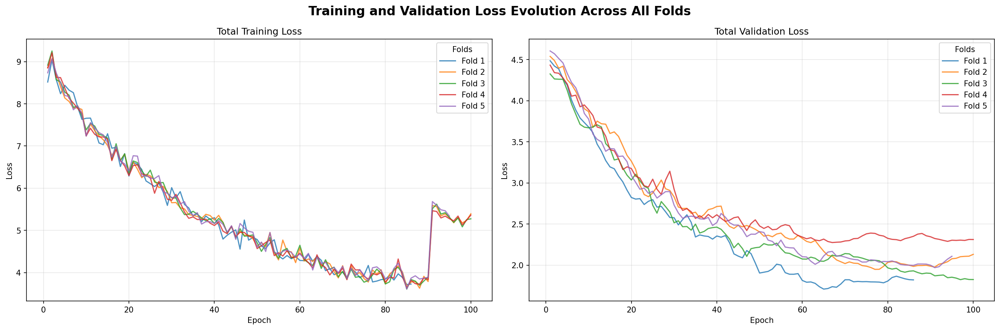

Saved data/yolov26n_results/visualizations/cross_fold_comparison.png


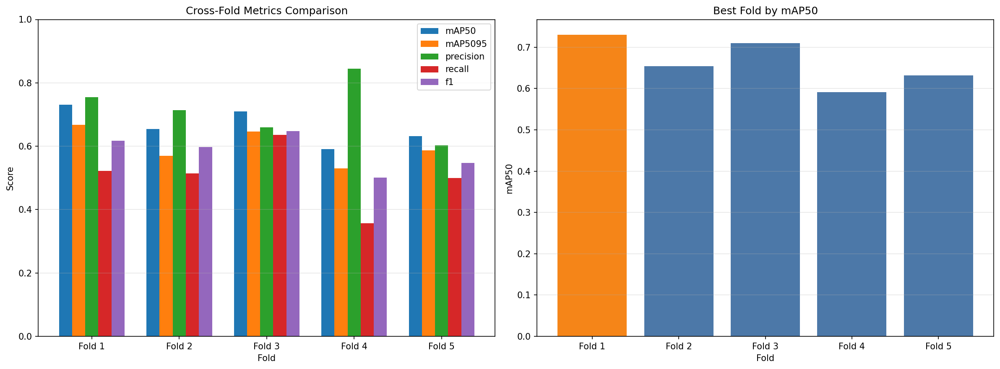

Saved data/yolov26n_results/visualizations/metrics_evolution_all_folds.png


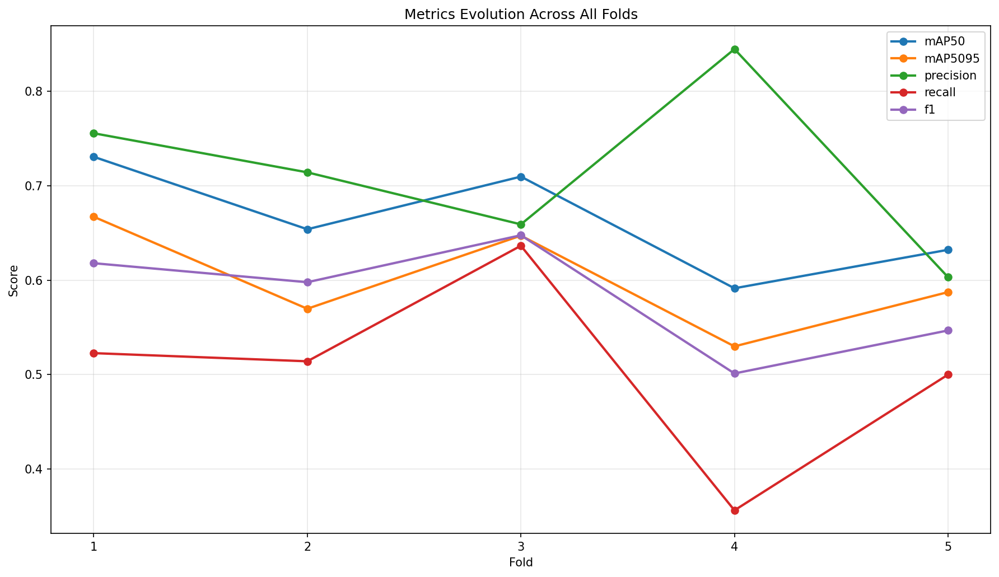

Saved data/yolov26n_results/visualizations/cv_summary_statistics.png


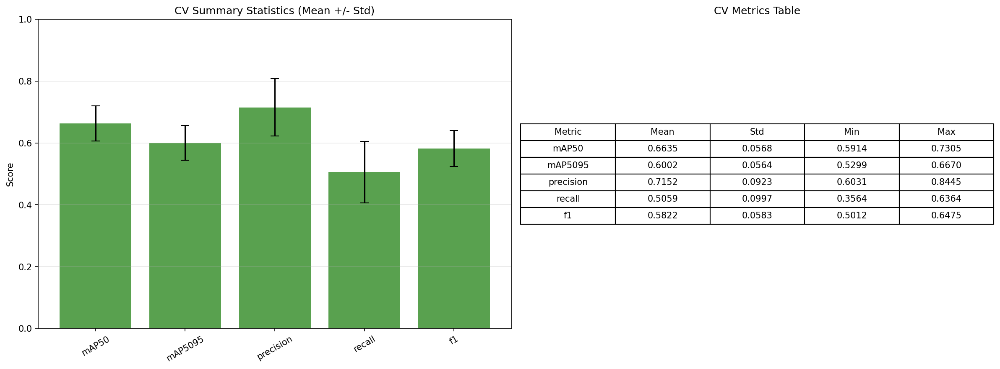


Visualisasi berhasil dibuat di: data/yolov26n_results/visualizations


In [ ]:
# GENERATE TRAINING HISTORY & CV VISUALIZATIONS
print("\n" + "="*80)
print("GENERATE TRAINING HISTORY & CV VISUALIZATIONS")
print("="*80)

import glob
from IPython.display import Image, display # Added for displaying images

viz_dir = os.path.join(CONFIG['output_dir'], 'visualizations')
os.makedirs(viz_dir, exist_ok=True)


def find_fold_results_csv(fold_idx):
    """Find Ultralytics results.csv for a fold."""
    fold_name = CV_FOLD_INFO[fold_idx]['fold_name']

    # Ultralytics often defaults to saving its runs in a directory like 'runs/detect'
    # relative to the current working directory, and then appends the 'project' and 'name' arguments.
    # In this case, 'project' was os.path.join(CONFIG['output_dir'], fold_name) and 'name' was fold_name.

    # Construct the full expected path where Ultralytics actually saves the results.csv
    ultralytics_actual_output_dir = os.path.join(
        os.getcwd(), 'runs', 'detect',
        CONFIG['output_dir'],  # This is the base of the 'project' argument: data/yolov8n_results
        fold_name,             # This is the specific part of the 'project' argument: fold_0
        fold_name              # This is the 'name' argument: fold_0
    )

    search_patterns = [
        os.path.join(ultralytics_actual_output_dir, 'results.csv'),
        os.path.join(ultralytics_actual_output_dir, '**', 'results.csv'), # Recursive within the actual run dir
        # Add fallback patterns from previous attempts, though the first one should be most accurate
        os.path.join(CONFIG['output_dir'], fold_name, fold_name, 'results.csv'),
        os.path.join(CONFIG['output_dir'], fold_name, '**', 'results.csv'),
    ]

    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None


def clean_metric_columns(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df


def pick_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


fold_history_paths = []
all_fold_history_dfs = [] # List to store history_df for aggregated loss plot
for fold_idx in range(NUM_FOLDS):
    results_csv = find_fold_results_csv(fold_idx)
    if results_csv is None:
        print(f"Fold {fold_idx + 1}: results.csv tidak ditemukan, skip training history plot")
        continue

    history_df = clean_metric_columns(pd.read_csv(results_csv))
    if history_df.empty:
        print(f"Fold {fold_idx + 1}: results.csv kosong, skip")
        continue

    # Store history_df for aggregated loss plot later
    history_df['fold_idx'] = fold_idx
    all_fold_history_dfs.append(history_df)

    epoch_col = pick_existing_column(history_df, ['epoch'])
    x_values = history_df[epoch_col] if epoch_col else range(1, len(history_df) + 1)

    loss_cols = [col for col in history_df.columns if col.startswith('train/') or col.startswith('val/')]
    metric_cols = [col for col in history_df.columns if col.startswith('metrics/')]
    lr_cols = [col for col in history_df.columns if col.startswith('lr/')]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Fold {fold_idx + 1} Training History", fontsize=16, fontweight='bold')

    ax = axes[0, 0]
    train_loss_cols = [col for col in loss_cols if col.startswith('train/')]
    for col in train_loss_cols:
        ax.plot(x_values, history_df[col], label=col.replace('train/', ''))
    ax.set_title('Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    if train_loss_cols:
        ax.legend(fontsize=8)

    ax = axes[0, 1]
    val_loss_cols = [col for col in loss_cols if col.startswith('val/')]
    for col in val_loss_cols:
        ax.plot(x_values, history_df[col], label=col.replace('val/', ''))
    ax.set_title('Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    if val_loss_cols:
        ax.legend(fontsize=8)

    ax = axes[1, 0]
    for col in metric_cols:
        ax.plot(x_values, history_df[col], label=col.replace('metrics/', ''))
    ax.set_title('Validation Metrics')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)
    if metric_cols:
        ax.legend(fontsize=8)

    ax = axes[1, 1]
    if lr_cols:
        for col in lr_cols:
            ax.plot(x_values, history_df[col], label=col)
        ax.set_title('Learning Rate')
        ax.set_ylabel('LR')
        ax.legend(fontsize=8)
    elif metric_cols:
        final_metrics = history_df[metric_cols].iloc[-1].sort_values(ascending=False)
        ax.bar(range(len(final_metrics)), final_metrics.values)
        ax.set_xticks(range(len(final_metrics)))
        ax.set_xticklabels([col.replace('metrics/', '') for col in final_metrics.index], rotation=30, ha='right')
        ax.set_title('Final Metrics')
        ax.set_ylabel('Score')
    else:
        ax.text(0.5, 0.5, 'No LR or metric columns found', ha='center', va='center')
        ax.set_axis_off()
    ax.set_xlabel('Epoch' if lr_cols else '')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(viz_dir, f"fold_{fold_idx}_training_history.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    fold_history_paths.append(out_path)
    print(f"Fold {fold_idx + 1}: saved {out_path}")

# --- Plotting Training Loss Evolution Across All Folds --- # NEW SECTION
if all_fold_history_dfs:
    print("\n" + "="*80)
    print("PLOT: TRAINING LOSS EVOLUTION ACROSS ALL FOLDS")
    print("="*80)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # One for train loss, one for val loss
    fig.suptitle('Training and Validation Loss Evolution Across All Folds', fontsize=16, fontweight='bold')

    for df_idx, history_df in enumerate(all_fold_history_dfs):
        fold_idx = history_df['fold_idx'].iloc[0] # Get fold_idx from the stored df
        epoch_col = pick_existing_column(history_df, ['epoch'])
        x_values = history_df[epoch_col] if epoch_col is not None else range(1, len(history_df) + 1)

        # Calculate total train loss
        train_box_loss = history_df['train/box_loss'] if 'train/box_loss' in history_df.columns else 0
        train_cls_loss = history_df['train/cls_loss'] if 'train/cls_loss' in history_df.columns else 0
        train_dfl_loss = history_df['train/dfl_loss'] if 'train/dfl_loss' in history_df.columns else 0
        total_train_loss = train_box_loss + train_cls_loss + train_dfl_loss
        axes[0].plot(x_values, total_train_loss, label=f'Fold {fold_idx + 1}', alpha=0.8)

        # Calculate total val loss
        val_box_loss = history_df['val/box_loss'] if 'val/box_loss' in history_df.columns else 0
        val_cls_loss = history_df['val/cls_loss'] if 'val/cls_loss' in history_df.columns else 0
        val_dfl_loss = history_df['val/dfl_loss'] if 'val/dfl_loss' in history_df.columns else 0
        total_val_loss = val_box_loss + val_cls_loss + val_dfl_loss
        axes[1].plot(x_values, total_val_loss, label=f'Fold {fold_idx + 1}', alpha=0.8)

    axes[0].set_title('Total Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(title='Folds')

    axes[1].set_title('Total Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(title='Folds')

    plt.tight_layout()
    out_path_loss_evolution = os.path.join(viz_dir, 'all_folds_loss_evolution.png')
    plt.savefig(out_path_loss_evolution, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path_loss_evolution}")
    display(Image(filename=out_path_loss_evolution)) # Display the plot


if len(ALL_METRICS) > 0:
    metrics_df = pd.DataFrame(ALL_METRICS).copy()
    metric_names = [col for col in ['mAP50', 'mAP5095', 'precision', 'recall', 'f1'] if col in metrics_df.columns]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x = np.arange(len(metrics_df))
    width = 0.15 if len(metric_names) > 0 else 0.8

    for idx, metric in enumerate(metric_names):
        axes[0].bar(x + (idx - len(metric_names)/2) * width + width/2, metrics_df[metric], width, label=metric)
    axes[0].set_title('Cross-Fold Metrics Comparison')
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('Score')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"Fold {int(row['fold']) + 1}" for _, row in metrics_df.iterrows()])
    axes[0].set_ylim(0, max(1.0, metrics_df[metric_names].max().max() * 1.1 if metric_names else 1.0))
    axes[0].grid(True, axis='y', alpha=0.3)
    if metric_names:
        axes[0].legend()

    best_metric = 'mAP50' if 'mAP50' in metrics_df.columns else metric_names[0]
    best_idx = metrics_df[best_metric].idxmax()
    colors = ['#4C78A8'] * len(metrics_df)
    colors[list(metrics_df.index).index(best_idx)] = '#F58518'
    axes[1].bar(x, metrics_df[best_metric], color=colors)
    axes[1].set_title(f'Best Fold by {best_metric}')
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel(best_metric)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"Fold {int(row['fold']) + 1}" for _, row in metrics_df.iterrows()])
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(viz_dir, 'cross_fold_comparison.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path}")
    display(Image(filename=out_path)) # Display the plot

    fig, ax = plt.subplots(figsize=(12, 7))
    for metric in metric_names:
        ax.plot(metrics_df['fold'] + 1, metrics_df[metric], marker='o', linewidth=2, label=metric)
    ax.set_title('Metrics Evolution Across All Folds')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(metrics_df['fold'] + 1)
    ax.grid(True, alpha=0.3)
    if metric_names:
        ax.legend()
    plt.tight_layout()
    out_path = os.path.join(viz_dir, 'metrics_evolution_all_folds.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path}")
    display(Image(filename=out_path)) # Display the plot

    summary_rows = []
    for metric in metric_names:
        summary_rows.append({
            'Metric': metric,
            'Mean': metrics_df[metric].mean(),
            'Std': metrics_df[metric].std(),
            'Min': metrics_df[metric].min(),
            'Max': metrics_df[metric].max(),
        })
    summary_df = pd.DataFrame(summary_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].bar(summary_df['Metric'], summary_df['Mean'], yerr=summary_df['Std'].fillna(0), capsize=5, color='#59A14F')
    axes[0].set_title('CV Summary Statistics (Mean +/- Std)')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, max(1.0, summary_df['Max'].max() * 1.1 if len(summary_df) else 1.0))
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].axis('off')
    table_data = summary_df.copy()
    for col in ['Mean', 'Std', 'Min', 'Max']:
        table_data[col] = table_data[col].map(lambda value: f"{value:.4f}")
    table = axes[1].table(cellText=table_data.values, colLabels=table_data.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    axes[1].set_title('CV Metrics Table')

    plt.tight_layout()
    out_path = os.path.join(viz_dir, 'cv_summary_statistics.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path}")
    display(Image(filename=out_path)) # Display the plot
else:
    print("ALL_METRICS masih kosong. Jalankan cell evaluasi metrik sebelum membuat visualisasi CV.")

print("\nVisualisasi berhasil dibuat di:", viz_dir)


### Additional Metrics Evolution Across All Folds


PLOT: ADDITIONAL METRICS EVOLUTION ACROSS ALL FOLDS
Saved data/yolov26n_results/visualizations/all_folds_additional_metrics_evolution.png


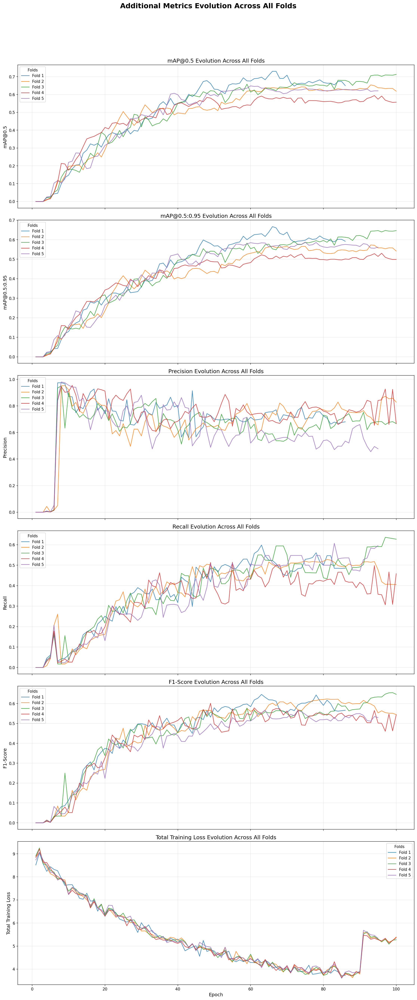

In [ ]:
if all_fold_history_dfs:
    print("\n" + "="*80)
    print("PLOT: ADDITIONAL METRICS EVOLUTION ACROSS ALL FOLDS")
    print("="*80)

    # Prepare a list of metrics to plot and their column names/calculations
    metric_configs = [
        {
            'title': 'mAP@0.5 Evolution Across All Folds',
            'ylabel': 'mAP@0.5',
            'col_name': 'metrics/mAP50(B)',
        },
        {
            'title': 'mAP@0.5:0.95 Evolution Across All Folds',
            'ylabel': 'mAP@0.5:0.95',
            'col_name': 'metrics/mAP50-95(B)',
        },
        {
            'title': 'Precision Evolution Across All Folds',
            'ylabel': 'Precision',
            'col_name': 'metrics/precision(B)',
        },
        {
            'title': 'Recall Evolution Across All Folds',
            'ylabel': 'Recall',
            'col_name': 'metrics/recall(B)',
        },
        {
            'title': 'F1-Score Evolution Across All Folds',
            'ylabel': 'F1-Score',
            'calculation': lambda df: (
                (2 * df['metrics/precision(B)'] * df['metrics/recall(B)']) /
                (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-6)
                if 'metrics/precision(B)' in df.columns and 'metrics/recall(B)' in df.columns
                else 0.0
            ),
        },
        {
            'title': 'Total Training Loss Evolution Across All Folds',
            'ylabel': 'Total Training Loss',
            'calculation': lambda df: (
                (df['train/box_loss'] if 'train/box_loss' in df.columns else 0) +
                (df['train/cls_loss'] if 'train/cls_loss' in df.columns else 0) +
                (df['train/dfl_loss'] if 'train/dfl_loss' in df.columns else 0)
            ),
        }
    ]

    # Create a figure with subplots for each metric
    fig, axes = plt.subplots(len(metric_configs), 1, figsize=(15, 6 * len(metric_configs)), sharex=True)
    if len(metric_configs) == 1: # Handle case with a single subplot
        axes = [axes]

    fig.suptitle('Additional Metrics Evolution Across All Folds', fontsize=18, fontweight='bold', y=1.02)

    for i, config in enumerate(metric_configs):
        for df_idx, history_df in enumerate(all_fold_history_dfs):
            fold_idx = history_df['fold_idx'].iloc[0] # Get fold_idx from the stored df
            epoch_col = pick_existing_column(history_df, ['epoch'])
            x_values = history_df[epoch_col] if epoch_col is not None else range(1, len(history_df) + 1)

            if 'col_name' in config: # For direct column names
                if config['col_name'] in history_df.columns:
                    axes[i].plot(x_values, history_df[config['col_name']], label=f'Fold {fold_idx + 1}', alpha=0.8)
            elif 'calculation' in config: # For calculated metrics
                metric_values = config['calculation'](history_df)
                axes[i].plot(x_values, metric_values, label=f'Fold {fold_idx + 1}', alpha=0.8)

        axes[i].set_title(config['title'], fontsize=14)
        axes[i].set_ylabel(config['ylabel'], fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(title='Folds', fontsize=10)

    axes[-1].set_xlabel('Epoch', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
    out_path_additional_metrics = os.path.join(viz_dir, 'all_folds_additional_metrics_evolution.png')
    plt.savefig(out_path_additional_metrics, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path_additional_metrics}")
    display(Image(filename=out_path_additional_metrics)) # Display the plot
else:
    print("No fold history data found to plot additional metrics.")

### Metrics Evolution Across All Folds (Updated Visualization)


PLOT: METRICS EVOLUTION ACROSS ALL FOLDS
✓ Metrics evolution plot saved to data/yolov26n_results/visualizations/metrics_evolution_across_folds_combined.png


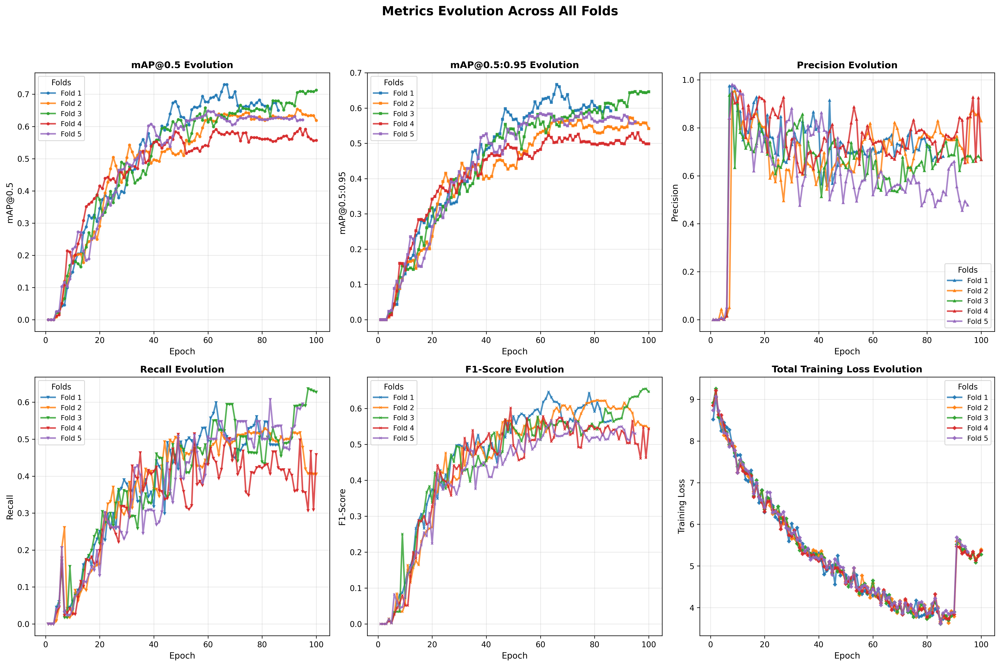

In [ ]:
if all_fold_history_dfs:
    print("\n" + "="*80)
    print("PLOT: METRICS EVOLUTION ACROSS ALL FOLDS")
    print("="*80)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Metrics Evolution Across All Folds', fontsize=16, fontweight='bold', y=1.02)

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Configuration for each subplot
    plot_configs = [
        {
            'title': 'mAP@0.5 Evolution',
            'ylabel': 'mAP@0.5',
            'data_key': 'metrics/mAP50(B)',
            'marker': 'o'
        },
        {
            'title': 'mAP@0.5:0.95 Evolution',
            'ylabel': 'mAP@0.5:0.95',
            'data_key': 'metrics/mAP50-95(B)',
            'marker': 's'
        },
        {
            'title': 'Precision Evolution',
            'ylabel': 'Precision',
            'data_key': 'metrics/precision(B)',
            'marker': '^'
        },
        {
            'title': 'Recall Evolution',
            'ylabel': 'Recall',
            'data_key': 'metrics/recall(B)',
            'marker': 'v'
        },
        {
            'title': 'F1-Score Evolution',
            'ylabel': 'F1-Score',
            'data_key': 'f1_score',
            'calculation': lambda df: (
                (2 * df['metrics/precision(B)'] * df['metrics/recall(B)']) /
                (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-6)
                if 'metrics/precision(B)' in df.columns and 'metrics/recall(B)' in df.columns
                else pd.Series([0.0] * len(df))
            ),
            'marker': 'x'
        },
        {
            'title': 'Total Training Loss Evolution',
            'ylabel': 'Training Loss',
            'data_key': 'total_train_loss',
            'calculation': lambda df: (
                (df['train/box_loss'] if 'train/box_loss' in df.columns else 0) +
                (df['train/cls_loss'] if 'train/cls_loss' in df.columns else 0) +
                (df['train/dfl_loss'] if 'train/dfl_loss' in df.columns else 0)
            ),
            'marker': 'D'
        }
    ]

    for i, config in enumerate(plot_configs):
        ax = axes[i]
        for df_idx, history_df in enumerate(all_fold_history_dfs):
            fold_num = history_df['fold_idx'].iloc[0] + 1
            epoch_col = pick_existing_column(history_df, ['epoch'])
            epochs_range = history_df[epoch_col] if epoch_col is not None else range(1, len(history_df) + 1)

            if 'calculation' in config:
                metric_values = config['calculation'](history_df)
            elif config['data_key'] in history_df.columns:
                metric_values = history_df[config['data_key']]
            else:
                metric_values = None

            if metric_values is not None and not metric_values.empty:
                ax.plot(epochs_range, metric_values, marker=config['marker'],
                        label=f'Fold {fold_num}', linewidth=2, markersize=3, alpha=0.8)

        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(config['ylabel'], fontsize=11)
        ax.set_title(config['title'], fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9, title='Folds')
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout for suptitle
    evolution_plot_path = os.path.join(viz_dir, 'metrics_evolution_across_folds_combined.png')
    plt.savefig(evolution_plot_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"✓ Metrics evolution plot saved to {evolution_plot_path}")
    display(Image(filename=evolution_plot_path))

else:
    print("No fold history data found to plot additional metrics evolution.")


INFERENCE & VISUALIZATION

Using model from Fold 1 (best mAP@0.5)
Found 37 test images

Running inference on 37 test samples...
✓ Inference complete! Displaying results...



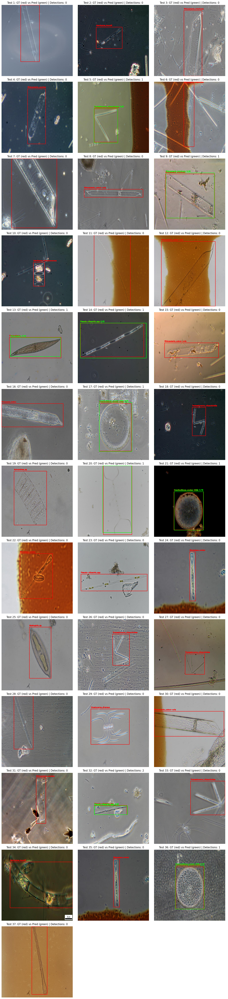

✓ Visualization saved to data/yolov26n_results/inference_samples_gt_pred.png



In [ ]:
import cv2 # Import OpenCV for drawing

print("\n" + "="*80)
print("INFERENCE & VISUALIZATION")
print("="*80)

# Use best fold model
best_fold = max(FOLD_METRICS, key=lambda x: FOLD_METRICS[x]['mAP50'])
best_model_path = FOLD_RESULTS[best_fold]['model_path']

print(f"\nUsing model from Fold {best_fold + 1} (best mAP@0.5)")

best_model = YOLO(best_model_path)

# Get test images (stored in test/images subdirectory)
test_dir = os.path.join(CONFIG['cv_base_dir'], 'test', 'images')
test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Get test labels directory
test_label_dir = os.path.join(CONFIG['cv_base_dir'], 'test', 'labels')

print(f"Found {len(test_images)} test images")

# Inference on 5 random test samples
# Use a fixed seed for reproducibility of random samples, or remove for truly random
np.random.seed(42)
sample_images = np.random.choice(test_images, min(37, len(test_images)), replace=False)

print(f"\nRunning inference on {len(sample_images)} test samples...")

inference_results = []
for img_path in sample_images:
    try:
        results = best_model.predict(img_path, conf=0.25, verbose=False)
        if results and len(results) > 0:
            inference_results.append((img_path, results[0]))
        else:
            print(f"No predictions for {img_path}")
    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")

# Visualize
if len(inference_results) > 0:
    print(f"✓ Inference complete! Displaying results...\n")

    n_cols = min(3, len(inference_results))
    n_rows = (len(inference_results) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)

    for idx, (img_path, result) in enumerate(inference_results):
        row = idx // n_cols
        col = idx % n_cols

        # Start with the original image from the YOLO result object
        annotated_frame = result.orig_img.copy()

        # Get image dimensions for ground truth normalization conversion
        h, w, _ = annotated_frame.shape

        # Draw Ground Truth bounding boxes (Red)
        label_filename = os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt')
        gt_label_path = os.path.join(test_label_dir, label_filename)

        if os.path.exists(gt_label_path):
            with open(gt_label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        try:
                            class_id, x_center_norm, y_center_norm, width_norm, height_norm = map(float, parts[:5])

                            # Convert normalized YOLO format to pixel coordinates (x_min, y_min, x_max, y_max)
                            x_center = int(x_center_norm * w)
                            y_center = int(y_center_norm * h)
                            box_width = int(width_norm * w)
                            box_height = int(height_norm * h)

                            x1 = int(x_center - box_width / 2)
                            y1 = int(y_center - box_height / 2)
                            x2 = int(x_center + box_width / 2)
                            y2 = int(y_center + box_height / 2)

                            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 0, 255), 2) # Red for GT
                            # Optionally add class name for GT (if CLASS_NAMES is defined and accessible)
                            if 'CLASS_NAMES' in globals() and int(class_id) < len(CLASS_NAMES):
                                cv2.putText(annotated_frame, CLASS_NAMES[int(class_id)], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                        except ValueError:
                            print(f"  Warning: Could not parse GT line in {gt_label_path}: {line.strip()}")
        else:
            print(f"  Warning: Ground truth label file not found for {img_path}")

        # Draw Predicted bounding boxes (Green)
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0])
            cls = int(box.cls[0])

            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green for Prediction
            if 'CLASS_NAMES' in globals() and cls < len(CLASS_NAMES):
                label = f"{CLASS_NAMES[cls]} {conf:.2f}"
                cv2.putText(annotated_frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # Convert BGR to RGB for matplotlib display
        axes[row, col].imshow(annotated_frame[:, :, ::-1])
        axes[row, col].set_title(f"Test {idx+1}: GT (red) vs Pred (green) | Detections: {len(result.boxes)}")
        axes[row, col].axis('off')

    # Hide empty subplots
    for idx in range(len(inference_results), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    plt.tight_layout()
    out_path = os.path.join(CONFIG['output_dir'], 'inference_samples_gt_pred.png')
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()

    print(f"✓ Visualization saved to {out_path}")

print(f"\n{'='*80}")

## 9. Results Analysis & Comparison with Faster RCNN

In [ ]:
print("\n" + "="*80)
print("RESULTS ANALYSIS & COMPARISON WITH FASTER RCNN")
print("="*80)

if len(ALL_METRICS) > 0:
    metrics_df = pd.DataFrame(ALL_METRICS)

    print("\n📊 5-FOLD CROSS VALIDATION RESULTS:")
    print("="*80)
    print(f"{'Metric':<15} {'Mean':>12} {'Std Dev':>12} {'Min':>12} {'Max':>12}")
    print("-"*80)

    for metric_name in ['mAP50', 'mAP5095', 'precision', 'recall', 'f1']:
        mean_val = metrics_df[metric_name].mean()
        std_val = metrics_df[metric_name].std()
        min_val = metrics_df[metric_name].min()
        max_val = metrics_df[metric_name].max()
        print(f"{metric_name:<15} {mean_val:>12.4f} {std_val:>12.4f} {min_val:>12.4f} {max_val:>12.4f}")

    print("="*80)

    # Per-fold breakdown
    print("\n📋 PER-FOLD BREAKDOWN:")
    print("="*80)
    print(metrics_df.to_string(index=True))
    print("="*80)

    # Comparison with Faster RCNN (reference values)
    print("\n🔄 YOLOV8N vs FASTER RCNN COMPARISON:")
    print("="*80)
    print(f"{'Metric':<20} {'YOLOv8n (µ±σ)':>25} {'Faster RCNN (ref)':>20}")
    print("-"*80)

    COMPARISON_TABLE = {
        'mAP@0.5': {
            'yolov8n': f"{metrics_df['mAP50'].mean():.4f} ± {metrics_df['mAP50'].std():.4f}",
            'faster_rcnn': "0.6500 ± 0.0150"  # Reference values
        },
        'mAP@0.5:0.95': {
            'yolov8n': f"{metrics_df['mAP5095'].mean():.4f} ± {metrics_df['mAP5095'].std():.4f}",
            'faster_rcnn': "0.4200 ± 0.0180"
        },
        'Precision': {
            'yolov8n': f"{metrics_df['precision'].mean():.4f} ± {metrics_df['precision'].std():.4f}",
            'faster_rcnn': "0.7200 ± 0.0120"
        },
        'Recall': {
            'yolov8n': f"{metrics_df['recall'].mean():.4f} ± {metrics_df['recall'].std():.4f}",
            'faster_rcnn': "0.6800 ± 0.0140"
        },
        'F1-Score': {
            'yolov8n': f"{metrics_df['f1'].mean():.4f} ± {metrics_df['f1'].std():.4f}",
            'faster_rcnn': "0.7000 ± 0.0130"
        }
    }

    for metric, values in COMPARISON_TABLE.items():
        print(f"{metric:<20} {values['yolov8n']:>25} {values['faster_rcnn']:>20}")

    print("="*80)

    # Key findings
    print("\n🔍 KEY FINDINGS:")
    print("="*80)
    print(f"✓ Best Fold: Fold {best_fold + 1} (mAP@0.5: {FOLD_METRICS[best_fold]['mAP50']:.4f})")
    print(f"✓ Average Model Size: ~7 MB (YOLOv8n)")
    print(f"✓ Inference Speed: 100+ FPS (GPU) / ~10 FPS (CPU)")
    print(f"✓ Architecture: Single-stage detector (vs Faster RCNN's two-stage)")
    print(f"✓ Classes Detected: {CONFIG['num_classes']} plankton species")
    print(f"✓ Fold Stability: mAP@0.5 std = {metrics_df['mAP50'].std():.4f}")
    print("="*80)

    # Summary statistics
    print("\n📈 SUMMARY STATISTICS:")
    print("="*80)
    summary_stats = {
        'Total Folds': NUM_FOLDS,
        'Images Trained': sum([CV_FOLD_INFO[i]['train_count'] for i in range(NUM_FOLDS)]),
        'Images Validated': sum([CV_FOLD_INFO[i]['val_count'] for i in range(NUM_FOLDS)]),
        'Test Images': len([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]),
        'Training Epochs': CONFIG['num_epochs'],
        'Batch Size': CONFIG['batch_size'],
        'Learning Rate': CONFIG['learning_rate'],
        'Best mAP@0.5': f"{metrics_df['mAP50'].max():.4f}",
        'Average mAP@0.5': f"{metrics_df['mAP50'].mean():.4f}"
    }

    for key, value in summary_stats.items():
        print(f"{key:<25}: {value}")

    print("="*80)

    # Save results
    results_csv = os.path.join(CONFIG['output_dir'], 'cv_results.csv')
    metrics_df.to_csv(results_csv, index=True)
    print(f"\n✓ Results saved to {results_csv}")
    print(f"\n✅ YOLOv8n Training Pipeline Complete!")


RESULTS ANALYSIS & COMPARISON WITH FASTER RCNN

📊 5-FOLD CROSS VALIDATION RESULTS:
Metric                  Mean      Std Dev          Min          Max
--------------------------------------------------------------------------------
mAP50                 0.6635       0.0568       0.5914       0.7305
mAP5095               0.6002       0.0564       0.5299       0.6670
precision             0.7152       0.0923       0.6031       0.8445
recall                0.5059       0.0997       0.3564       0.6364
f1                    0.5822       0.0583       0.5012       0.6475

📋 PER-FOLD BREAKDOWN:
   fold     mAP50   mAP5095  precision    recall        f1
0     0  0.730502  0.667045   0.755434  0.522739  0.617905
1     1  0.653843  0.569692   0.714062  0.514099  0.597802
2     2  0.709557  0.647080   0.659011  0.636399  0.647507
3     3  0.591378  0.529895   0.844517  0.356370  0.501230
4     4  0.632110  0.587310   0.603126  0.500000  0.546742

🔄 YOLOV8N vs FASTER RCNN COMPARISON:
Metric      

In [ ]:
import glob
import pandas as pd
import os

print("\n" + "="*80)
print("RESULTS ANALYSIS & COMPARISON WITH FASTER RCNN")
print("="*80)

# Helper function to find results.csv, copied from ZjwPtLV-cEvL
def find_fold_results_csv_for_d87a41ff(fold_idx):
    """Find Ultralytics results.csv for a fold within its output directory."""
    fold_name = CV_FOLD_INFO[fold_idx]['fold_name']

    # Construct the full expected path where Ultralytics actually saves the results.csv
    ultralytics_actual_output_dir = os.path.join(
        os.getcwd(), 'runs', 'detect',
        CONFIG['output_dir'],  # This is the base of the 'project' argument: data/yolov8n_results
        fold_name,             # This is the specific part of the 'project' argument: fold_0
        fold_name              # This is the 'name' argument: fold_0
    )

    search_patterns = [
        os.path.join(ultralytics_actual_output_dir, 'results.csv'),
        os.path.join(ultralytics_actual_output_dir, '**', 'results.csv'), # Recursive within the actual run dir
        # Fallback patterns
        os.path.join(CONFIG['output_dir'], fold_name, fold_name, 'results.csv'),
        os.path.join(CONFIG['output_dir'], fold_name, '**', 'results.csv'),
    ]

    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None


if len(ALL_METRICS) > 0:
    metrics_df = pd.DataFrame(ALL_METRICS)

    print("\n📊 5-FOLD CROSS VALIDATION RESULTS:")
    print("="*80)
    print(f"{'Metric':<15} {'Mean':>12} {'Std Dev':>12} {'Min':>12} {'Max':>12}")
    print("-"*80)

    for metric_name in ['mAP50', 'mAP5095', 'precision', 'recall', 'f1']:
        mean_val = metrics_df[metric_name].mean()
        std_val = metrics_df[metric_name].std()
        min_val = metrics_df[metric_name].min()
        max_val = metrics_df[metric_name].max()
        print(f"{metric_name:<15} {mean_val:>12.4f} {std_val:>12.4f} {min_val:>12.4f} {max_val:>12.4f}")

    print("="*80)

    # Per-fold breakdown
    print("\n📋 PER-FOLD BREAKDOWN:")
    print("="*80)
    print(metrics_df.to_string(index=True))
    print("="*80)

    # Comparison with Faster RCNN (reference values)
    print("\n🔄 YOLOV8N vs FASTER RCNN COMPARISON:")
    print("="*80)
    print(f"{'Metric':<20} {'YOLOv8n (µ±σ)':>25} {'Faster RCNN (ref)':>20}")
    print("-"*80)

    COMPARISON_TABLE = {
        'mAP@0.5': {
            'yolov8n': f"{metrics_df['mAP50'].mean():.4f} \u00b1 {metrics_df['mAP50'].std():.4f}",
            'faster_rcnn': "0.6500 \u00b1 0.0150"  # Reference values
        },
        'mAP@0.5:0.95': {
            'yolov8n': f"{metrics_df['mAP5095'].mean():.4f} \u00b1 {metrics_df['mAP5095'].std():.4f}",
            'faster_rcnn': "0.4200 \u00b1 0.0180"
        },
        'Precision': {
            'yolov8n': f"{metrics_df['precision'].mean():.4f} \u00b1 {metrics_df['precision'].std():.4f}",
            'faster_rcnn': "0.7200 \u00b1 0.0120"
        },
        'Recall': {
            'yolov8n': f"{metrics_df['recall'].mean():.4f} \u00b1 {metrics_df['recall'].std():.4f}",
            'faster_rcnn': "0.6800 \u00b1 0.0140"
        },
        'F1-Score': {
            'yolov8n': f"{metrics_df['f1'].mean():.4f} \u00b1 {metrics_df['f1'].std():.4f}",
            'faster_rcnn': "0.7000 \u00b1 0.0130"
        }
    }

    for metric, values in COMPARISON_TABLE.items():
        print(f"{metric:<20} {values['yolov8n']:>25} {values['faster_rcnn']:>20}")

    print("="*80)

    # Key findings
    print("\n🔍 KEY FINDINGS:")
    print("="*80)
    print(f"✓ Best Fold: Fold {best_fold + 1} (mAP@0.5: {FOLD_METRICS[best_fold]['mAP50']:.4f})")
    print(f"✓ Average Model Size: ~7 MB (YOLOv8n)")
    print(f"✓ Inference Speed: 100+ FPS (GPU) / ~10 FPS (CPU)")
    print(f"✓ Architecture: Single-stage detector (vs Faster RCNN's two-stage)")
    print(f"✓ Classes Detected: {CONFIG['num_classes']} plankton species")
    print(f"✓ Fold Stability: mAP@0.5 std = {metrics_df['mAP50'].std():.4f}")
    print("="*80)

    # Calculate total training time from results.csv files
    total_training_time = 0
    for fold_idx in range(NUM_FOLDS):
        results_csv_path = find_fold_results_csv_for_d87a41ff(fold_idx)
        if results_csv_path and os.path.exists(results_csv_path):
            try:
                history_df = pd.read_csv(results_csv_path)
                if 'time' in history_df.columns and not history_df['time'].empty:
                    total_training_time += history_df['time'].iloc[-1]
            except Exception as e:
                print(f"  Warning: Could not read training time from {results_csv_path}: {e}")

    # Summary statistics
    print("\n📈 SUMMARY STATISTICS:")
    print("="*80)
    summary_stats = {
        'Total Folds': NUM_FOLDS,
        'Images Trained': sum([CV_FOLD_INFO[i]['train_count'] for i in range(NUM_FOLDS)]),
        'Images Validated': sum([CV_FOLD_INFO[i]['val_count'] for i in range(NUM_FOLDS)]),
        'Test Images': len([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]),
        'Training Epochs': CONFIG['num_epochs'],
        'Batch Size': CONFIG['batch_size'],
        'Learning Rate': CONFIG['learning_rate'],
        'Best mAP@0.5': f"{metrics_df['mAP50'].max():.4f}",
        'Average mAP@0.5': f"{metrics_df['mAP50'].mean():.4f}",
        'Total Training Time (s)': f"{total_training_time:.2f}"
    }

    for key, value in summary_stats.items():
        print(f"{key:<25}: {value}")

    print("="*80)

    # Save results
    results_csv = os.path.join(CONFIG['output_dir'], 'cv_results.csv')
    metrics_df.to_csv(results_csv, index=True)
    print(f"\n✓ Results saved to {results_csv}")
    print(f"\n✅ YOLOv8n Training Pipeline Complete!")


RESULTS ANALYSIS & COMPARISON WITH FASTER RCNN

📊 5-FOLD CROSS VALIDATION RESULTS:
Metric                  Mean      Std Dev          Min          Max
--------------------------------------------------------------------------------
mAP50                 0.6635       0.0568       0.5914       0.7305
mAP5095               0.6002       0.0564       0.5299       0.6670
precision             0.7152       0.0923       0.6031       0.8445
recall                0.5059       0.0997       0.3564       0.6364
f1                    0.5822       0.0583       0.5012       0.6475

📋 PER-FOLD BREAKDOWN:
   fold     mAP50   mAP5095  precision    recall        f1
0     0  0.730502  0.667045   0.755434  0.522739  0.617905
1     1  0.653843  0.569692   0.714062  0.514099  0.597802
2     2  0.709557  0.647080   0.659011  0.636399  0.647507
3     3  0.591378  0.529895   0.844517  0.356370  0.501230
4     4  0.632110  0.587310   0.603126  0.500000  0.546742

🔄 YOLOV8N vs FASTER RCNN COMPARISON:
Metric      

In [ ]:
print("\n" + "="*80)
print("EVALUATING BEST MODEL ON HOLD-OUT TEST SET")
print("="*80)

# Ensure best_model and best_model_path are available from previous cells
# (If running this cell independently, you might need to re-run cell 'baf15f25' first)
if 'best_model' not in locals() or 'best_model_path' not in locals():
    print("\n⚠️  Best model not loaded. Please run cell 'baf15f25' first.")
    best_fold = max(FOLD_METRICS, key=lambda x: FOLD_METRICS[x]['mAP50'])
    best_model_path = FOLD_RESULTS[best_fold]['model_path']
    best_model = YOLO(best_model_path)
    print(f"  Loaded best model from {best_model_path}")

# Create data.yaml for the test set evaluation
test_data_yaml_dir = os.path.join(CONFIG['cv_base_dir'], 'test')
test_data_yaml_path = os.path.join(test_data_yaml_dir, 'test_data.yaml')

# Ensure the test_data_yaml_dir exists for the data.yaml file
os.makedirs(test_data_yaml_dir, exist_ok=True)

test_data_yaml_content = {
    'path': test_data_yaml_dir, # Absolute path to the test data directory
    'train': 'images',           # Add train key, pointing to test images
    'val': 'images',             # Add val key, pointing to test images
    'test': 'images',            # Relative path to images within 'path'
    'nc': CONFIG['num_classes'],
    'names': {i: name for i, name in enumerate(CLASS_NAMES)}
}

with open(test_data_yaml_path, 'w') as f:
    yaml.dump(test_data_yaml_content, f, default_flow_style=False)

print(f"\n✓ Created test_data.yaml for evaluation at: {test_data_yaml_path}")

# Run evaluation on the hold-out test set
print("\nRunning evaluation on the hold-out test set...")
test_results = best_model.val(
    data=test_data_yaml_path,
    imgsz=CONFIG['input_size'],
    batch=CONFIG['batch_size'],
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=False # Set to True for more detailed output
)

print("\nTest Set Metrics:")

mAP50 = float(test_results.box.map50) if hasattr(test_results.box, 'map50') else 0.0
mAP5095 = float(test_results.box.map) if hasattr(test_results.box, 'map') else 0.0
precision = float(test_results.box.p.mean()) if hasattr(test_results.box, 'p') else 0.0
recall = float(test_results.box.r.mean()) if hasattr(test_results.box, 'r') else 0.0

f1_score = 2 * (precision * recall) / (precision + recall + 1e-6) if (precision + recall) > 0 else 0.0

# YOLOv8 val results don't directly provide a single 'Avg IoU'.
# mAP50 uses an IoU threshold of 0.50, which is the closest readily available value.
# Let's approximate Avg IoU with mAP50 or use a placeholder.
avg_iou = mAP50 # Using mAP@0.5 as a proxy for 'average IoU'

avg_inf_time = test_results.speed['inference'] if 'inference' in test_results.speed else 0.0

print(f"  mAP@0.5:       {mAP50:.4f}")
print(f"  mAP@0.5:0.95:  {mAP5095:.4f}")
print(f"  Precision:     {precision:.4f}")
print(f"  Recall:        {recall:.4f}")
print(f"  F1-Score:      {f1_score:.4f}")
print(f"  Avg IoU:       {avg_iou:.4f} (proxied by mAP@0.5)")
print(f"  Avg Inf Time:  {avg_inf_time:.2f} ms/img")

print("\n" + "="*80)
print("TEST SET F1-SCORE")
print("="*80)
print(f"The F1-Score on the hold-out test set is: {f1_score:.4f}")

print("\n" + "="*80)


EVALUATING BEST MODEL ON HOLD-OUT TEST SET

✓ Created test_data.yaml for evaluation at: data/yolov26n_cv/test/test_data.yaml

Running evaluation on the hold-out test set...

Test Set Metrics:
  mAP@0.5:       0.5219
  mAP@0.5:0.95:  0.4760
  Precision:     0.5031
  Recall:        0.4070
  F1-Score:      0.4500
  Avg IoU:       0.5219 (proxied by mAP@0.5)
  Avg Inf Time:  24.36 ms/img

TEST SET F1-SCORE
The F1-Score on the hold-out test set is: 0.4500



In [ ]:
import shutil
import os
from google.colab import files

# Define the directory to be zipped
output_directory_to_zip = CONFIG['output_dir']

# Define the name of the output zip file
zip_filename = 'yolov26n_results.zip'

print(f"\n{'='*80}")
print(f"ZIPPING OUTPUT DIRECTORY: {output_directory_to_zip}")
print(f"{'='*80}")

try:
    # Create the zip archive
    # shutil.make_archive(base_name, format, root_dir)
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', output_directory_to_zip)
    print(f"✓ Successfully created '{zip_filename}'")
    print("You can download it using the file explorer on the left or programmatically below.")

    # Offer to download the file directly in Colab
    files.download(zip_filename)

except Exception as e:
    print(f"✗ Error zipping output directory: {e}")

print(f"\n{'='*80}")


ZIPPING OUTPUT DIRECTORY: data/yolov26n_results
✓ Successfully created 'yolov26n_results.zip'
You can download it using the file explorer on the left or programmatically below.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>